In [3]:
import MDAnalysis as mda
from numpy import *
import os
from pylab import *
import MDAnalysis.analysis.distances
import MDAnalysis.analysis.rms
from MDAnalysis.analysis import align
import glob
#import umap
import scipy.stats
import sklearn
import sklearn.decomposition
import sklearn.preprocessing
import pandas as pd
import seaborn as sns
from MDAnalysis.analysis.hydrogenbonds.hbond_analysis import HydrogenBondAnalysis as HBA
import mdtraj

In [4]:
import os

########################################################
#############      FOR NOW EQPOINT IS 0   ##############
########################################################
EQPOINT=0

systemFolders = glob.glob("huNumbering/*t5a*/")

systemgros=[]
systemtprs=[]
systemtrjs=[]
for i in range(len(systemFolders)):
    systemgros.append(sorted(glob.glob(systemFolders[i]+"*.gro")))
    systemtprs.append(sorted(glob.glob(systemFolders[i]+"*.tpr")))
    systemtrjs.append(sorted(glob.glob(systemFolders[i]+"*.xtc")))


    
    
threeColor=["#FE6100","#332288","#882255"]
colourScheme= threeColor
system_names = ["rhT5A","T5A","T5AR332P"]
systems=[]
for i in range(len(systemgros)):
    sub=[]
    for j in range(len(systemgros[i])):
        # When using TPRs, residues are indexed from 1; so we need to add in the first residue, 1 - 1 + first resid=first resid
        #firstres = mda.Universe(systemgros[i][j]).residues.resids[0]-1
        tu = mda.Universe(systemgros[i][j],systemtrjs[i][j])
        #tu.residues.resids +=firstres
                          
        sub.append(tu)
        
    systems.append(sub)

rhresids = arange(291,495)
huresids = systems[1][0].residues.resids
    
protein=[]
proteinstrings=[]
for i in range(len(systems)):
    sub = []
    sub2 = []
    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein"))
        sub2.append("protein")
        
    protein.append(sub)
    proteinstrings.append(sub2)


bodys=[]
bodystrings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []
    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and not ("+combinedLoopString+")"))
        sub2.append("protein and not ("+combinedLoopString+")")
        
    bodys.append(sub)
    bodystrings.append(sub2)
    
    
v1s=[]
v1strings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []

    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and "+combinedLoopString))
        sub2.append("protein and "+combinedLoopString)

        
    v1s.append(sub)        
    v1strings.append(sub2)
                   

In [5]:
allsasa=[]
for i in range(len(systems)):
    sub=[]
    for j in range(len(systems[i])):
        
        trj = systemtrjs[i][j]
        tpr = systemgros[i][j]

        t = mdtraj.load(trj, top = tpr)
        sasa = mdtraj.shrake_rupley(t, mode='residue',probe_radius = 0.14)
        sub.append(sasa)
    allsasa.append(sub)


C:\Users\Liam\anaconda3\lib\site-packages\mdtraj\formats\gro.py:307: UserWarning: WARNING: two consecutive residues with same number (LEU, GLU)
  warnings.warn("WARNING: two consecutive residues with same number (%s, %s)" % (thisresname, residue.name))
C:\Users\Liam\anaconda3\lib\site-packages\mdtraj\formats\gro.py:307: UserWarning: WARNING: two consecutive residues with same number (THR, LEU)
  warnings.warn("WARNING: two consecutive residues with same number (%s, %s)" % (thisresname, residue.name))
C:\Users\Liam\anaconda3\lib\site-packages\mdtraj\formats\gro.py:307: UserWarning: WARNING: two consecutive residues with same number (ASP, THR)
  warnings.warn("WARNING: two consecutive residues with same number (%s, %s)" % (thisresname, residue.name))
C:\Users\Liam\anaconda3\lib\site-packages\mdtraj\formats\gro.py:307: UserWarning: WARNING: two consecutive residues with same number (ALA, ASP)
  warnings.warn("WARNING: two consecutive residues with same number (%s, %s)" % (thisresname, res

C:\Users\Liam\anaconda3\lib\site-packages\mdtraj\formats\gro.py:307: UserWarning: WARNING: two consecutive residues with same number (ARG, VAL)
  warnings.warn("WARNING: two consecutive residues with same number (%s, %s)" % (thisresname, residue.name))
C:\Users\Liam\anaconda3\lib\site-packages\mdtraj\formats\gro.py:307: UserWarning: WARNING: two consecutive residues with same number (ALA, VAL)
  warnings.warn("WARNING: two consecutive residues with same number (%s, %s)" % (thisresname, residue.name))
C:\Users\Liam\anaconda3\lib\site-packages\mdtraj\formats\gro.py:307: UserWarning: WARNING: two consecutive residues with same number (CYS, SER)
  warnings.warn("WARNING: two consecutive residues with same number (%s, %s)" % (thisresname, residue.name))
C:\Users\Liam\anaconda3\lib\site-packages\mdtraj\formats\gro.py:307: UserWarning: WARNING: two consecutive residues with same number (GLU, SER)
  warnings.warn("WARNING: two consecutive residues with same number (%s, %s)" % (thisresname, res

In [7]:
for i in range(len(allsasa)):
    save(system_names[i]+"allsasa.txt",allsasa[i])
#save("allsasa.npy",allsasa)
#allsasa = load("allsasa.npy")

In [13]:
len(allsasa[0])

9

In [18]:
def insertMyNans(huArray,indices=[338-290,338-290]):
    huList = list(huArray)
    # Note, index list should be in descending order, otherwise there will be problems 
    # (since the index of later indexes will increase every time you make an insertion)
    for i in range(len(indices)):
        huList.insert(indices[i],nan)
    return array(huList)
avg_sasa=[]
sem_sasa=[]
#for i in range(len(allsasa)):
#    if i !=0:
#        avg_sasa.append(insertMyNans(mean(mean(allsasa[i],axis = 0),axis =0)))
#        sem_sasa.append(insertMyNans(scipy.stats.sem(mean(allsasa[i],axis = 0),axis =0)))
#    else:
#        avg_sasa.append(mean(mean(allsasa[i],axis = 0),axis =0))
#        sem_sasa.append(scipy.stats.sem(mean(allsasa[i],axis = 1),axis =0))
    
for i in range(len(allsasa)):
    avg_sasa.append(mean(mean(allsasa[i],axis = 0),axis = 0))
    sem_sasa.append(scipy.stats.sem(mean(allsasa[i],axis = 1),axis = 0))


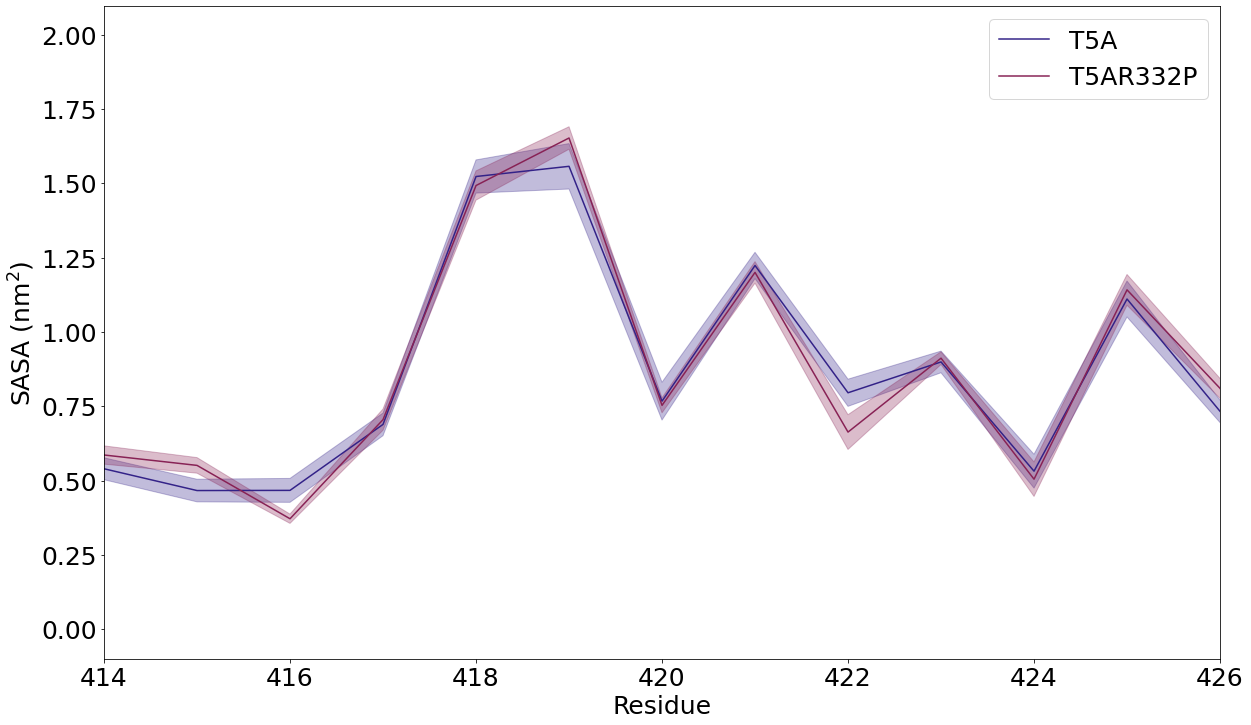

In [27]:
figure(figsize = (20,12))
for i in range(1,3):#len(avghelicities)):
    
    plot(huresids,avg_sasa[i],color = colourScheme[i],label = system_names[i])
    fill_between(huresids, avg_sasa[i] - sem_sasa[i],avg_sasa[i] + sem_sasa[i],color = colourScheme[i],alpha = 0.3)

    
xlabel("Residue",fontsize = 25)
ylabel("SASA (nm$^2$)",fontsize = 25)
xticks(fontsize = 25)
yticks(fontsize = 25)
legend(fontsize = 25)

xlim(414,426)
axvline(343)